## 1. Autoencoder Optuna + Stochastic + Regularization + Dropout + Early Stopping (Private Score)

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, losses
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.metrics import roc_auc_score

C:\Users\jarvis\AppData\Local\Temp\ipykernel_23696\4273985095.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dev_set = train_df.groupby('lettr').apply(lambda x: x.sample(n=min(len(x), row_per_class), random_state=SEED))
C:\Users\jarvis\AppData\Local\Temp\ipykernel_23696\4273985095.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_set = excluded_train_df.groupby('lettr').apply(lambda x: x.sample

Train: (3402, 16)
Val: (378, 16)
Dev: (550, 16)
Test: (1000, 16)
Entire (UCI test): (15757, 16)


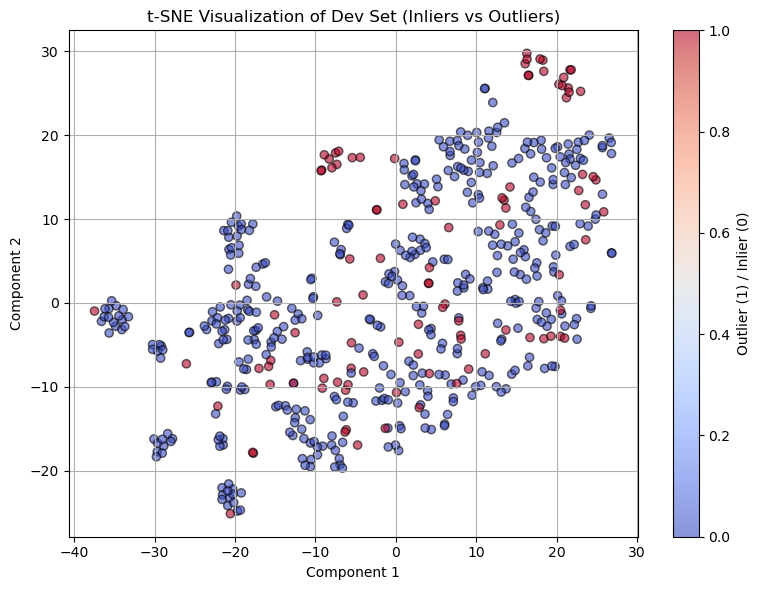

C:\Users\jarvis\AppData\Local\Temp\ipykernel_23696\4273985095.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=letter_counts.index, y=letter_counts.values, palette=palette)


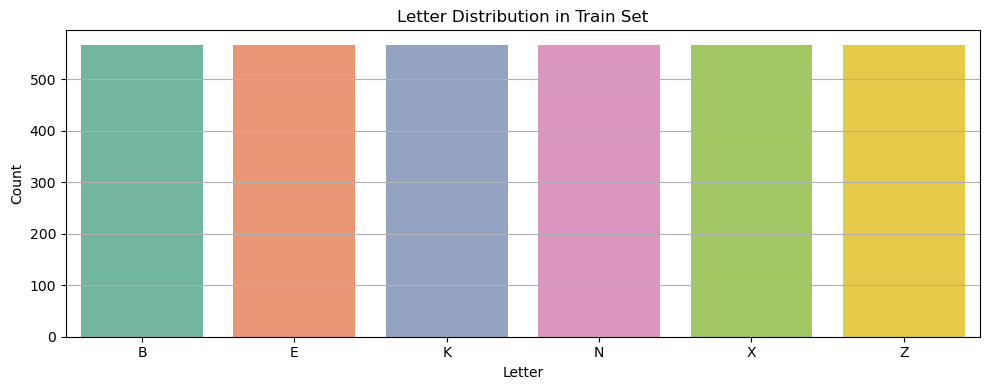

C:\Users\jarvis\AppData\Local\Temp\ipykernel_23696\4273985095.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=letter_counts.index, y=letter_counts.values, palette=palette)


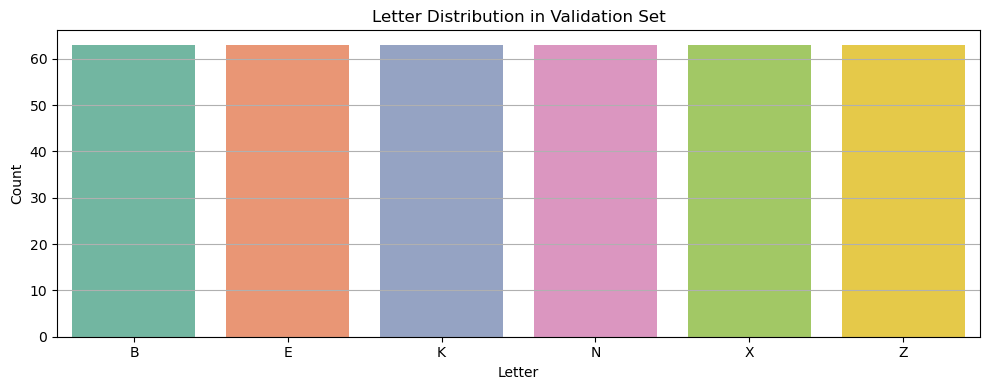

C:\Users\jarvis\AppData\Local\Temp\ipykernel_23696\4273985095.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=letter_counts.index, y=letter_counts.values, palette=palette)


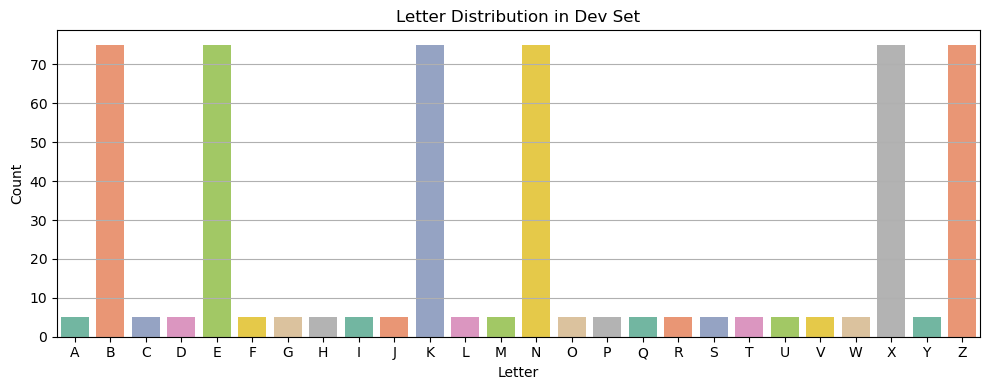

C:\Users\jarvis\AppData\Local\Temp\ipykernel_23696\4273985095.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=letter_counts.index, y=letter_counts.values, palette=palette)


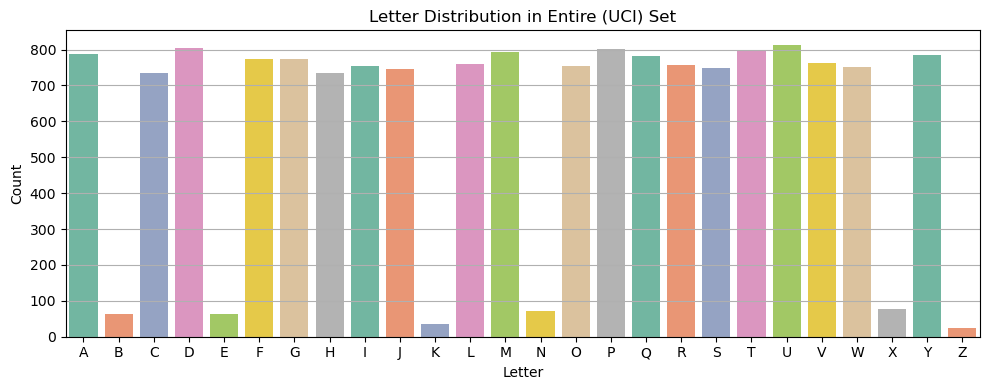

In [39]:
# Configuration
SEED = 42

# Data preprocessing
INLIERS = ['B', 'E', 'K', 'N', 'X', 'Z']

# load data
train_df = pd.read_csv("training.csv")
test_df = pd.read_csv("test_X.csv")
entire_df = pd.read_csv("entire_excluded_training.csv")

# build dev set --> checking overfitting
n_classes = len(train_df["lettr"].unique())
row_per_class = int((len(train_df) * 0.1) // n_classes)
dev_set = train_df.groupby('lettr').apply(lambda x: x.sample(n=min(len(x), row_per_class), random_state=SEED))
dev_set = dev_set.reset_index(level=0, drop=True)
excluded_train_df = train_df.drop(index=dev_set.index).reset_index(drop=True)
dev_set = dev_set.reset_index(drop=True)

# build validation set --> enhance model while running
row_per_class = int((len(excluded_train_df) * 0.1) // n_classes)
val_set = excluded_train_df.groupby('lettr').apply(lambda x: x.sample(n=min(len(x), row_per_class), random_state=SEED))
val_set = val_set.reset_index(level=0, drop=True)
excluded_train_df = excluded_train_df.drop(index=val_set.index).reset_index(drop=True)
val_set = val_set.reset_index(drop=True)

# ======================
# Label outliers in dev set and entire set
# ======================
entire_df["is_outlier"] = ~entire_df["lettr"].isin(INLIERS)
# add more 50 rows include outliers for dev-set --> no need to exclude they from entire set because we are not training on them
outlier_rows = entire_df[~entire_df["lettr"].isin(INLIERS)]
n_classes_entire = len(entire_df["lettr"].unique()) - len(train_df["lettr"].unique())
row_per_class_entire = int(100 // n_classes_entire)
outlier_part = entire_df.groupby('lettr').apply(lambda x: x.sample(n=min(len(x), row_per_class_entire), random_state=SEED)).reset_index(drop=True)
dev_set = pd.concat([dev_set, outlier_part], ignore_index=True)
dev_set["is_outlier"] = ~dev_set["lettr"].isin(INLIERS)


y_dev_true = dev_set["is_outlier"].astype(int).values
y_true_entire = entire_df["is_outlier"].astype(int).values

# ======================
# Split features (X) and remove labels
# ======================
X_train_full = excluded_train_df.drop(columns='lettr')
X_val = val_set.drop(columns='lettr')
X_dev = dev_set.drop(columns=['lettr', 'is_outlier'])
X_test = test_df.copy()
X_entire = entire_df.drop(columns=['lettr', 'is_outlier'])

# ======================
# Feature Scaling
# ======================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_val_scaled = scaler.transform(X_val)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)
X_entire_scaled = scaler.transform(X_entire)

# ======================
# Shapes for sanity check
# ======================
print("Train:", X_train_scaled.shape)
print("Val:", X_val_scaled.shape)
print("Dev:", X_dev_scaled.shape)
print("Test:", X_test_scaled.shape)
print("Entire (UCI test):", X_entire_scaled.shape)

# ======================
# Visualize data with low dimension and another chart for distributions all of them
# ======================
# Combine dev set with inlier/outlier labels
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED)
X_embedded = tsne.fit_transform(X_dev_scaled)

# Plot 2D t-SNE result
plt.figure(figsize=(8, 6))
plt.scatter(
    X_embedded[:, 0], X_embedded[:, 1],
    c=y_dev_true, cmap='coolwarm', alpha=0.6, edgecolors='k'
)
plt.title("t-SNE Visualization of Dev Set (Inliers vs Outliers)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Outlier (1) / Inlier (0)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================
# Function to plot bar chart
# ==========================
def plot_letter_distribution(df, title, label_column='lettr', figsize=(10, 4), palette='Set2'):
    letter_counts = df[label_column].value_counts().sort_index()
    plt.figure(figsize=figsize)
    sns.barplot(x=letter_counts.index, y=letter_counts.values, palette=palette)
    plt.title(title)
    plt.xlabel("Letter")
    plt.ylabel("Count")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# ==========================
# Plot distributions
# ==========================
plot_letter_distribution(excluded_train_df, "Letter Distribution in Train Set")
plot_letter_distribution(val_set, "Letter Distribution in Validation Set")
plot_letter_distribution(dev_set, "Letter Distribution in Dev Set")
plot_letter_distribution(entire_df, "Letter Distribution in Entire (UCI) Set")



🔁 Training model 1/4 with seed 42

🔁 Training model 2/4 with seed 52

🔁 Training model 3/4 with seed 62

🔁 Training model 4/4 with seed 72


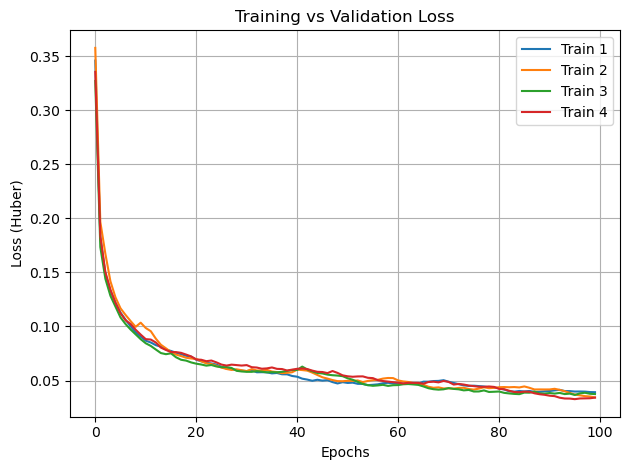


📉 Average minimum validation loss per model: nan
🧪 Mean Test Reconstruction MSE: 0.474042
🧪 AUC on Dev Set: 0.9362
📦 AUC on Entire UCI Set: 0.9267

✅ solution_1_submission_1_auc_.csv saved successfully!


d:\Softwares\anaconda3\envs\tensorflow\lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
d:\Softwares\anaconda3\envs\tensorflow\lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
# ========== Train/Validation Split ==========
X_train = X_train_scaled
X_val = X_val_scaled

# ========== Build Autoencoder ==========
def build_autoencoder(input_dim):
    model = models.Sequential([
        layers.Dense(128, input_shape=(input_dim,)),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),

        layers.Dense(64),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),

        layers.Dense(32),
        layers.LeakyReLU(alpha=0.1),

        layers.Dense(64),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),

        layers.Dense(128),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),

        layers.Dense(input_dim, activation='linear')
    ])
    return model
input_dim = X_train.shape[1]

# ========== Train Ensemble Models ==========
all_errors = []
all_errors_dev = []
all_errors_entire = []
seeds = [42, 52, 62, 72]
val_losses = []

for i, seed in enumerate(seeds):
    print(f"\n🔁 Training model {i+1}/{len(seeds)} with seed {seed}")
    tf.random.set_seed(seed)
    np.random.seed(seed)

    autoencoder = build_autoencoder(input_dim)
    autoencoder.compile(optimizer='adam', loss=losses.Huber(delta=1.0))

    early_stop = callbacks.EarlyStopping(patience=8, restore_best_weights=True)
    reduce_lr = callbacks.ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-5)

    history = autoencoder.fit(
        X_train, X_train,
        # validation_data=(X_val, X_val),
        epochs=100,
        batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # Plot training vs validation loss
    plt.plot(history.history['loss'], label=f"Train {i+1}")
    plt.plot(history.history['val_loss'], label=f"Val {i+1}")
    val_losses.append(min(history.history['val_loss']))

    # Predict on test set
    X_test_pred = autoencoder.predict(X_test_scaled, verbose=0)
    mse = np.mean(np.square(X_test_pred - X_test_scaled), axis=1)
    all_errors.append(mse)
    
    # === Predict on dev set ===
    X_dev_pred = autoencoder.predict(X_dev_scaled, verbose=0)
    mse_dev = np.mean(np.square(X_dev_pred - X_dev_scaled), axis=1)
    all_errors_dev.append(mse_dev)

    # === Predict on entire set ===
    X_entire_pred = autoencoder.predict(X_entire_scaled, verbose=0)
    mse_entire = np.mean(np.square(X_entire_pred - X_entire_scaled), axis=1)
    all_errors_entire.append(mse_entire)

# ========== Plot Loss Curve ==========
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (Huber)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ========== Print Error Info ==========
print(f"\n📉 Average minimum validation loss per model: {np.mean(val_losses):.6f}")

# Calculate average test reconstruction error
avg_error = np.mean(all_errors, axis=0)
avg_error_dev = np.mean(all_errors_dev, axis=0)
avg_error_entire = np.mean(all_errors_entire, axis=0)
print(f"🧪 Mean Test Reconstruction MSE: {np.mean(avg_error):.6f}")

# ========== Ensemble & Normalize ==========
outlier_scores = RobustScaler().fit_transform(avg_error.reshape(-1, 1)).flatten()
dev_scores = RobustScaler().fit_transform(avg_error_dev.reshape(-1, 1)).flatten()
entire_scores = RobustScaler().fit_transform(avg_error_entire.reshape(-1, 1)).flatten()

# Evaluate
auc_dev = roc_auc_score(y_dev_true, dev_scores)
auc_entire = roc_auc_score(y_true_entire, entire_scores)

print(f"🧪 AUC on Dev Set: {auc_dev:.4f}")
print(f"📦 AUC on Entire UCI Set: {auc_entire:.4f}")

# ========== Create Submission ==========
submission = pd.DataFrame({
    'id': np.arange(len(outlier_scores)),
    'outliers': outlier_scores
})

submission_name = "solution_1_submission_1_auc_"

submission.to_csv(f'{submission_name}.csv', index=False, float_format='%.9f')
print(f"\n✅ {submission_name}.csv saved successfully!")


## 2. AE + Optuna (Public Score)

In [17]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import seaborn as sns
import optuna

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Is using:", device)
INLIERS = ['B', 'E', 'K', 'N', 'X', 'Z']
SEED = 42

Is using: cuda


d:\Softwares\anaconda3\envs\tensorflow\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\jarvis\AppData\Local\Temp\ipykernel_14088\1156508185.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  inlier_part = inlier_rows.groupby('lettr').apply(lambda x: x.sample(n=inlier_nums, random_state=SEED)).reset_index(drop=True)
C:\Users\jarvis\AppData\Local\Temp\ipykernel_14088\1156508185.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outlier_part = outlier_rows.groupby('lettr').apply(lam

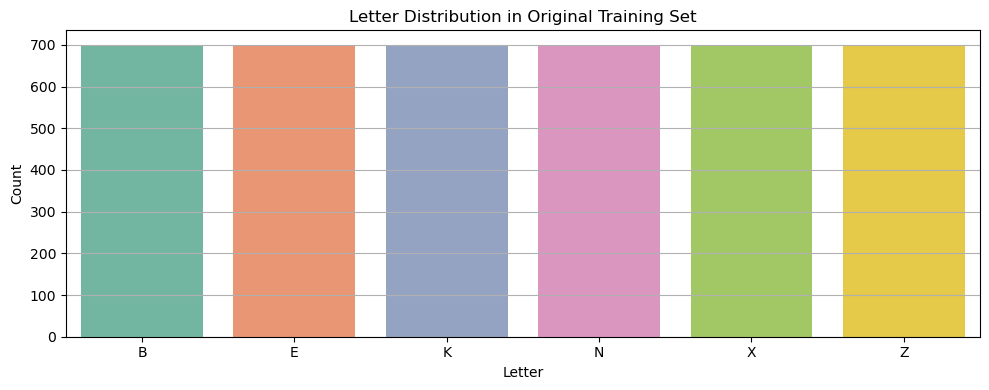

C:\Users\jarvis\AppData\Local\Temp\ipykernel_14088\1156508185.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=label_column, order=sorted(df[label_column].unique()), palette=palette)


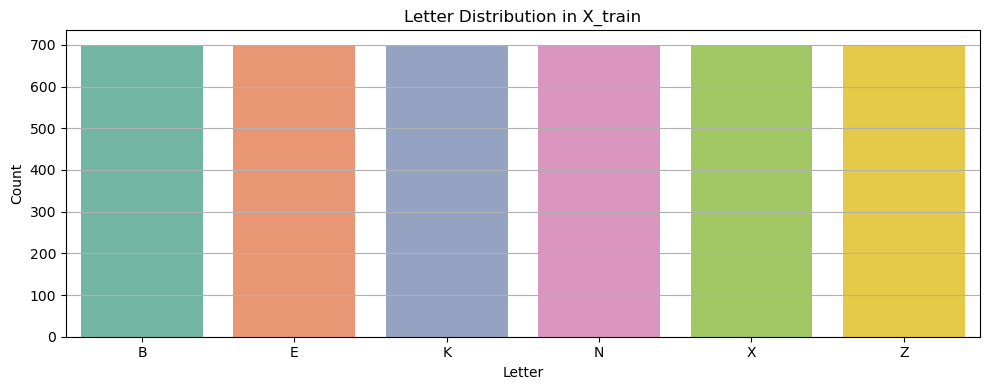

C:\Users\jarvis\AppData\Local\Temp\ipykernel_14088\1156508185.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=label_column, order=sorted(df[label_column].unique()), palette=palette)


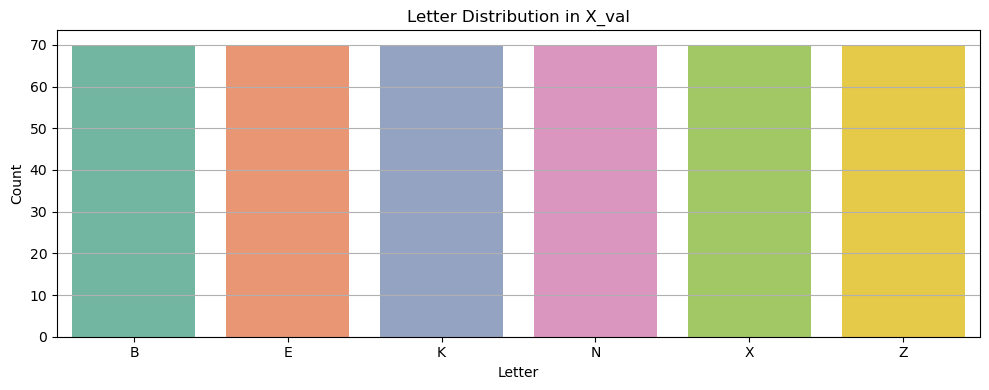

C:\Users\jarvis\AppData\Local\Temp\ipykernel_14088\1156508185.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=label_column, order=sorted(df[label_column].unique()), palette=palette)


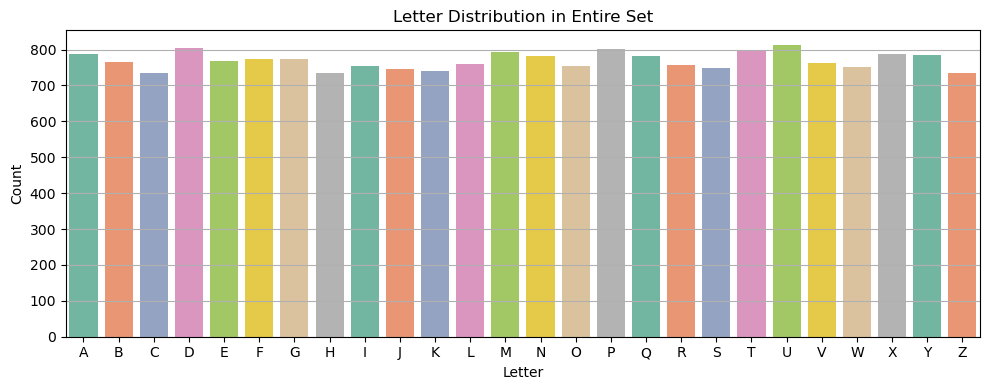

C:\Users\jarvis\AppData\Local\Temp\ipykernel_14088\1156508185.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=label_column, order=sorted(df[label_column].unique()), palette=palette)


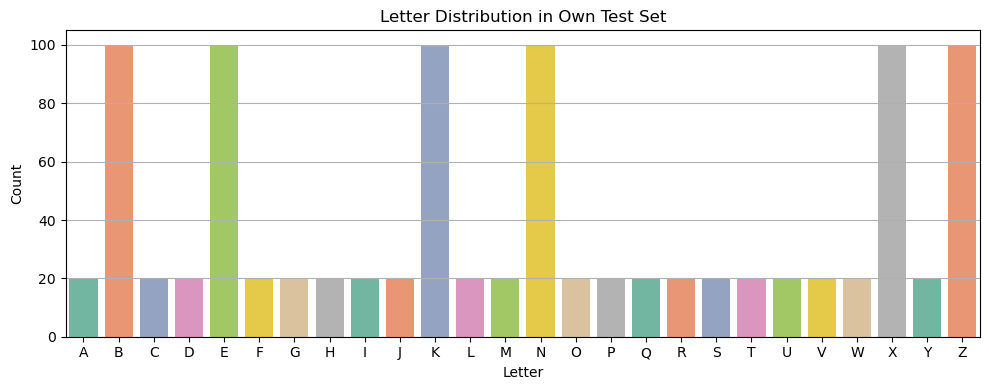

In [33]:
# load data
entire_df = pd.read_csv('entire.csv')
train_df = pd.read_csv('training.csv')
test_df = pd.read_csv('test_X.csv')

# preprocessing
X_train = train_df.drop(columns=["lettr"])
# y_train = train_df["lettr"]
# X_train, X_val, _, y_val = train_test_split(X_train_full, y_train_full, stratify=y_train_full, test_size=0.1, random_state=SEED)
# y_val_true = np.array([0 if y in INLIERS else 1 for y in y_val])
X_test = test_df.copy()

# build own_test
inlier_nums = 600 // len(INLIERS) # 100 each
outlier_nums = 400 // (len(entire_df["lettr"].unique()) - len(INLIERS)) # 20 each
inlier_rows = entire_df[entire_df["lettr"].isin(INLIERS)]
outlier_rows = entire_df[~entire_df["lettr"].isin(INLIERS)]
inlier_part = inlier_rows.groupby('lettr').apply(lambda x: x.sample(n=inlier_nums, random_state=SEED)).reset_index(drop=True)
outlier_part = outlier_rows.groupby('lettr').apply(lambda x: x.sample(n=outlier_nums, random_state=SEED)).reset_index(drop=True)
own_test_df = pd.concat([inlier_part, outlier_part], ignore_index=True)
own_test_df = own_test_df.reset_index(drop=True)

X_own_test = own_test_df.drop(columns=["lettr"], axis=1)
own_test_df["is_outlier"] = own_test_df["lettr"].apply(lambda x: 0 if x in INLIERS else 1)
y_own_test = own_test_df["is_outlier"]

# scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_own_test_scaled = scaler.transform(X_own_test)

# X_train_scaled = X_train
# X_test_scaled = X_test
# X_own_test_scaled = X_own_test

def plot_letter_distribution(df, label_column='lettr', title='Letter Distribution', palette='Set2'):
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=label_column, order=sorted(df[label_column].unique()), palette=palette)
    plt.title(title)
    plt.xlabel("Letter")
    plt.ylabel("Count")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# Plot distributions
plot_letter_distribution(train_df, title="Letter Distribution in Original Training Set")
plot_letter_distribution(train_df.iloc[X_train.index], title="Letter Distribution in X_train")
plot_letter_distribution(train_df.iloc[X_val.index], title="Letter Distribution in X_val")
plot_letter_distribution(entire_df, title="Letter Distribution in Entire Set")
plot_letter_distribution(own_test_df, title="Letter Distribution in Own Test Set")

📈 Epoch 001 | Train Loss: 0.258795 | Own Test AUC: 0.7234
📈 Epoch 002 | Train Loss: 0.164652 | Own Test AUC: 0.7825
📈 Epoch 003 | Train Loss: 0.145706 | Own Test AUC: 0.8907
📈 Epoch 004 | Train Loss: 0.133197 | Own Test AUC: 0.8869
📈 Epoch 005 | Train Loss: 0.124290 | Own Test AUC: 0.9077
📈 Epoch 006 | Train Loss: 0.119080 | Own Test AUC: 0.9140
📈 Epoch 007 | Train Loss: 0.112046 | Own Test AUC: 0.9185
📈 Epoch 008 | Train Loss: 0.110257 | Own Test AUC: 0.9127
📈 Epoch 009 | Train Loss: 0.111773 | Own Test AUC: 0.9216
📈 Epoch 010 | Train Loss: 0.104567 | Own Test AUC: 0.9236
📈 Epoch 011 | Train Loss: 0.104556 | Own Test AUC: 0.9301
📈 Epoch 012 | Train Loss: 0.098555 | Own Test AUC: 0.9264
📈 Epoch 013 | Train Loss: 0.095868 | Own Test AUC: 0.9337
📈 Epoch 014 | Train Loss: 0.097922 | Own Test AUC: 0.9343
📈 Epoch 015 | Train Loss: 0.097178 | Own Test AUC: 0.9349
📈 Epoch 016 | Train Loss: 0.093196 | Own Test AUC: 0.9425
📈 Epoch 017 | Train Loss: 0.091201 | Own Test AUC: 0.9431
📈 Epoch 018 | 

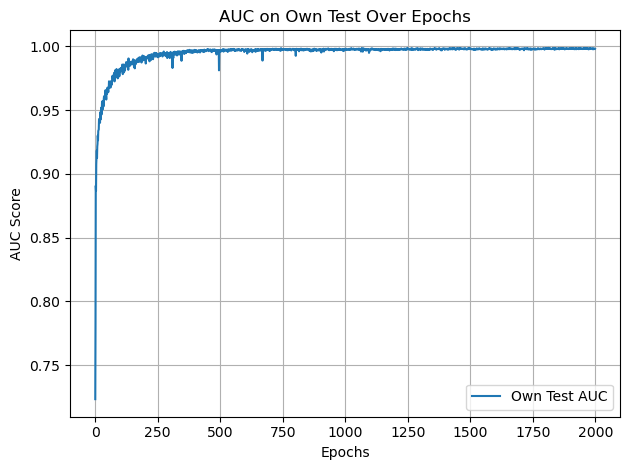

✅ Submission saved to solution_4_submission_pytorch_deepautoencoder_.csv


In [ ]:
# ========= Build Deep Autoencoder =========
class DeepAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(DeepAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(512),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(256),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(32),
            nn.Linear(32, 16),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(16),
            nn.Linear(16, 8),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(8),
            nn.Linear(8,4),
            nn.LeakyReLU(0.1),
        )
        self.decoder = nn.Sequential(
            nn.Linear(4,8),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(8),
            nn.Linear(8, 16),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(16),
            nn.Linear(16, 32),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(32),
            nn.Linear(32, 64),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(64),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(128),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(256),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(512),
            nn.Linear(512, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# ========= Prepare Data =========
def to_loader(X, batch_size=128, shuffle=False):
    if isinstance(X, pd.DataFrame):
        X = X.values  # Convert DataFrame to NumPy array
    X_tensor = torch.tensor(X, dtype=torch.float32)
    return DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train_scaled, shuffle=True)
val_loader = to_loader(X_val_scaled)
test_loader = to_loader(X_test_scaled)
own_test_loader = to_loader(X_own_test_scaled)

# ========= Training Function with AUC Logging =========
def train_with_auc(
    model, train_loader, own_loader, y_own, 
    epochs=100, patience=8, lr=1e-3, device='cuda'
):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.SmoothL1Loss()

    best_auc = -1
    best_model = None
    own_aucs = []
    no_improve = 0

    for epoch in range(epochs):
        # Training loop
        model.train()
        total_loss = 0
        for batch in train_loader:
            x = batch[0].to(device)
            optimizer.zero_grad()
            recon = model(x)
            loss = criterion(recon, x)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Evaluation on own_test
        model.eval()
        errors = []
        with torch.no_grad():
            for batch in own_loader:
                x = batch[0].to(device)
                recon = model(x)
                mse = F.mse_loss(recon, x, reduction='none').mean(dim=1)
                errors.extend(mse.cpu().numpy())

        scaled_errors = RobustScaler().fit_transform(np.array(errors).reshape(-1, 1)).flatten()
        own_auc = roc_auc_score(y_own, scaled_errors)
        own_aucs.append(own_auc)

        print(f"📈 Epoch {epoch+1:03d} | Train Loss: {total_loss/len(train_loader):.6f} | Own Test AUC: {own_auc:.4f}")

        if own_auc > best_auc:
            best_auc = own_auc
            best_model = model.state_dict()

    model.load_state_dict(best_model)
    return model, own_aucs


# ========= Run Training =========
input_dim = X_train_scaled.shape[1]
model = DeepAutoencoder(input_dim)
model, own_aucs = train_with_auc(
    model,
    train_loader,
    own_test_loader,
    y_own_test,
    epochs=2000,
    patience=10,
    lr=1e-3,
    device=device
)

# ========= Plot AUC Curves =========
plt.plot(own_aucs, label='Own Test AUC')
plt.xlabel("Epochs")
plt.ylabel("AUC Score")
plt.title("AUC on Own Test Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ========= Predict on Test Set =========
model.eval()
test_errors = []

with torch.no_grad():
    for batch in test_loader:
        x = batch[0].to(device)
        recon = model(x)
        mse = F.mse_loss(recon, x, reduction='none').mean(dim=1)
        test_errors.extend(mse.cpu().numpy())

# ========= Normalize Test Scores =========
test_errors = np.array(test_errors)
# normalized_scores = RobustScaler().fit_transform(test_errors.reshape(-1, 1)).flatten()
normalized_scores = test_errors.reshape(-1, 1).flatten()

# ========= Create Submission =========
submission = pd.DataFrame({
    'id': np.arange(len(normalized_scores)),
    'outliers': normalized_scores
})

# ========= Save Submission =========
submission_name = "solution_4_submission_pytorch_deepautoencoder_.csv"
submission.to_csv(submission_name, index=False, float_format='%.9f')
print(f"✅ Submission saved to {submission_name}")

In [19]:
def objective(trial):
    # Suggest hyperparameters
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    # Model architecture stays fixed, but you could optionally add suggestions for layer sizes or dropout

    # Prepare dataloaders
    train_loader_opt = to_loader(X_train_scaled, batch_size=batch_size, shuffle=True)
    own_loader_opt = to_loader(X_own_test_scaled, batch_size=batch_size)

    # Initialize model
    input_dim = X_train_scaled.shape[1]
    model = DeepAutoencoder(input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.SmoothL1Loss()

    model.train()
    for epoch in range(30):  # Short run for tuning
        total_loss = 0
        for batch in train_loader_opt:
            x = batch[0].to(device)
            optimizer.zero_grad()
            recon = model(x)
            loss = criterion(recon, x)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

    # Evaluation on own_test
    model.eval()
    errors = []
    with torch.no_grad():
        for batch in own_loader_opt:
            x = batch[0].to(device)
            recon = model(x)
            mse = F.mse_loss(recon, x, reduction='none').mean(dim=1)
            errors.extend(mse.cpu().numpy())

    scaled_errors = RobustScaler().fit_transform(np.array(errors).reshape(-1, 1)).flatten()
    auc = roc_auc_score(y_own_test, scaled_errors)
    recon_error = np.mean(errors)

    # Combine AUC and reconstruction error (maximize AUC, minimize error)
    score = auc - 0.1 * recon_error  # You can tweak weight on error

    trial.set_user_attr("auc", auc)
    trial.set_user_attr("recon_error", recon_error)

    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)

# Print best results
best_trial = study.best_trial
print("✅ Best Trial:")
print(f"AUC: {best_trial.user_attrs['auc']:.5f}")
print(f"Reconstruction Error: {best_trial.user_attrs['recon_error']:.6f}")
print(f"Params: {best_trial.params}")

[I 2025-04-19 21:24:20,966] A new study created in memory with name: no-name-e35f64c2-15c5-4e1f-9210-2173450c1a42
[I 2025-04-19 21:24:34,343] Trial 0 finished with value: 0.8783835410356521 and parameters: {'batch_size': 64, 'lr': 0.0003555542662600209}. Best is trial 0 with value: 0.8783835410356521.
[I 2025-04-19 21:24:46,013] Trial 1 finished with value: 0.8720499731043975 and parameters: {'batch_size': 64, 'lr': 0.00017957927326996584}. Best is trial 0 with value: 0.8783835410356521.
[W 2025-04-19 21:24:48,733] Trial 2 failed with parameters: {'batch_size': 256, 'lr': 0.0002427738142873276} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "d:\Softwares\anaconda3\envs\tensorflow\lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\jarvis\AppData\Local\Temp\ipykernel_14088\1227167317.py", line 24, in objective
    recon = model(x)
  File "d:\Softwares\anaconda3\envs\tenso

KeyboardInterrupt: 

In [ ]:
best_params = best_trial.params
batch_size = best_params["batch_size"]
lr = best_params["lr"]

# Prepare dataloaders with best params
train_loader = to_loader(X_train_scaled, batch_size=batch_size, shuffle=True)
own_loader = to_loader(X_own_test_scaled, batch_size=batch_size)

# Reinitialize model
model = DeepAutoencoder(input_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.SmoothL1Loss()

# Retrain fully
print("🔁 Retraining final model...")
for epoch in range(300):
    model.train()
    total_loss = 0
    for batch in train_loader:
        x = batch[0].to(device)
        optimizer.zero_grad()
        recon = model(x)
        loss = criterion(recon, x)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1} | Train Loss: {total_loss/len(train_loader):.6f}")

# ========= Predict on Test Set =========
model.eval()
test_errors = []

with torch.no_grad():
    for batch in test_loader:
        x = batch[0].to(device)
        recon = model(x)
        mse = F.mse_loss(recon, x, reduction='none').mean(dim=1)
        test_errors.extend(mse.cpu().numpy())

# ========= Normalize Test Scores =========
test_errors = np.array(test_errors)
normalized_scores = RobustScaler().fit_transform(test_errors.reshape(-1, 1)).flatten()

# ========= Create Submission =========
submission = pd.DataFrame({
    'id': np.arange(len(normalized_scores)),
    'outliers': normalized_scores
})

# ========= Save Submission =========
submission_name = "solution_4_submission_pytorch_deepautoencoder.csv"
submission.to_csv(submission_name, index=False, float_format='%.9f')
print(f"✅ Submission saved to {submission_name}")

## 3. SVM (Private Score)

In [29]:
# ================================
# 📌 One-Class SVM for Anomaly Detection
# ================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score

# ================================
# STEP 1: Load and Prepare Data
# ================================
# Define known inlier letters
INLIERS = ['B', 'E', 'K', 'N', 'X', 'Z']
SEED = 42
# Load datasets
train_df = pd.read_csv('training.csv')                   # Training data (inliers only)
test_df = pd.read_csv('test_X.csv')                      # Test set (Kaggle submission)
entire_df = pd.read_csv('entire_excluded_training.csv')

# build dev set --> checking overfitting
n_classes = len(train_df["lettr"].unique())
row_per_class = int((len(train_df) * 0.1) // n_classes)
dev_df = train_df.groupby('lettr').apply(lambda x: x.sample(n=min(len(x), row_per_class), random_state=SEED))
dev_df = dev_df.reset_index(level=0, drop=True)
excluded_train_df = train_df.drop(index=dev_df.index).reset_index(drop=True)
dev_df = dev_df.reset_index(drop=True)

entire_df["is_outlier"] = ~entire_df["lettr"].isin(INLIERS)
# add more 50 rows include outliers for dev-set --> no need to exclude they from entire set because we are not training on them
outlier_rows = entire_df[~entire_df["lettr"].isin(INLIERS)]
n_classes_entire = len(entire_df["lettr"].unique()) - len(train_df["lettr"].unique())
row_per_class_entire = int(100 // n_classes_entire)
outlier_part = outlier_rows.groupby('lettr').apply(lambda x: x.sample(n=min(len(x), row_per_class_entire), random_state=SEED)).reset_index(drop=True)
dev_df = pd.concat([dev_df, outlier_part], ignore_index=True)
dev_df["is_outlier"] = ~dev_df["lettr"].isin(INLIERS)

# Extract features from train and test sets
X_train = excluded_train_df.drop(columns=['lettr']).values.astype(np.float64)
X_test = test_df.values.astype(np.float64)


# Prepare validation set if labels are available
if 'lettr' in entire_df.columns:
    X_val = entire_df.drop(columns=['lettr', 'is_outlier']).values.astype(np.float64)
    y_val = entire_df['lettr'].apply(lambda x: 0 if x in INLIERS else 1).values.astype(int)
else:
    X_val, y_val = None, None
    
# Prepare validation set if labels are available
if 'lettr' in dev_df.columns:
    X_dev = dev_df.drop(columns=['lettr', 'is_outlier']).values.astype(np.float64)
    y_dev = dev_df['lettr'].apply(lambda x: 0 if x in INLIERS else 1).values.astype(int)
else:
    X_dev, y_dev = None, None

# ================================
# STEP 2: Feature Scaling
# ================================

# Standardize features based on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
if X_val is not None:
    X_val_scaled = scaler.transform(X_val)
if X_dev is not None:
    X_dev_scaled = scaler.transform(X_dev)

# ================================
# STEP 3: Train One-Class SVM Model
# ================================

print("🚀 Training One-Class SVM...")
ocsvm = OneClassSVM(kernel='rbf', gamma=5, nu=0.05)
ocsvm.fit(X_train_scaled)

# ================================
# STEP 4: Predict Outlier Scores
# ================================

# Anomaly score = -decision_function (higher = more anomalous)
svm_scores_raw = -ocsvm.decision_function(X_test_scaled)

# Normalize scores to [0, 1]
svm_scores = RobustScaler().fit_transform(svm_scores_raw.reshape(-1, 1)).flatten()

# ================================
# STEP 5: Optional Validation AUC
# ================================

if X_val is not None and y_val is not None:
    val_scores_raw = -ocsvm.decision_function(X_val_scaled)
    val_scores = RobustScaler().fit_transform(val_scores_raw.reshape(-1, 1)).flatten()
    val_auc = roc_auc_score(y_val, val_scores)
    print(f"🎯 Validation AUC (One-Class SVM): {val_auc:.6f}")

if X_dev is not None and y_dev is not None:
    dev_scores_raw = -ocsvm.decision_function(X_dev_scaled)
    dev_scores = RobustScaler().fit_transform(dev_scores_raw.reshape(-1, 1)).flatten()
    dev_auc = roc_auc_score(y_dev, dev_scores)
    print(f"🎯 Dev AUC (One-Class SVM): {dev_auc:.6f}")

# ================================
# STEP 6: Save Kaggle Submission
# ================================

submission = pd.DataFrame({
    'id': np.arange(len(svm_scores)),
    'outliers': svm_scores
})

submission_name = "solution_2_submission_2_auc_"

submission.to_csv(f'{submission_name}.csv', index=False, float_format='%.9f')
print(f"✅ Saved submission file: {submission_name}.csv")


C:\Users\jarvis\AppData\Local\Temp\ipykernel_23696\2616014330.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dev_df = train_df.groupby('lettr').apply(lambda x: x.sample(n=min(len(x), row_per_class), random_state=SEED))
C:\Users\jarvis\AppData\Local\Temp\ipykernel_23696\2616014330.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outlier_part = outlier_rows.groupby('lettr').apply(lambda x: x.sample(

🚀 Training One-Class SVM...
🎯 Validation AUC (One-Class SVM): 0.966077
🎯 Dev AUC (One-Class SVM): 0.972905
✅ Saved submission file: solution_2_submission_2_auc_.csv
